# Recomendation : <span style="font-weight:normal">Rekomendasi film</span>

<hr style="border:1px solid gray">

#### <span style="font-weight:normal">Proyek Submission 2 - Machine Learning Terapan <br/><br/> Oleh: Okta Agnes L. Manik</span>

# **Data Loading**

Mengambil Data dari Website Grouplens

In [2]:
# Langkah 1: Unduh file zip dari URL
!wget -O ml-latest-small.zip https://files.grouplens.org/datasets/movielens/ml-latest-small.zip

# Langkah 2: Unzip file
!unzip ml-latest-small.zip

--2025-02-12 04:57:06--  https://files.grouplens.org/datasets/movielens/ml-latest-small.zip
Resolving files.grouplens.org (files.grouplens.org)... 128.101.65.152
Connecting to files.grouplens.org (files.grouplens.org)|128.101.65.152|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 978202 (955K) [application/zip]
Saving to: ‘ml-latest-small.zip’

ml-latest-small.zip 100%[===================>] 955.28K   832KB/s    in 1.1s    

2025-02-12 04:57:09 (832 KB/s) - ‘ml-latest-small.zip’ saved [978202/978202]

Archive:  ml-latest-small.zip
   creating: ml-latest-small/
  inflating: ml-latest-small/links.csv  
  inflating: ml-latest-small/tags.csv  
  inflating: ml-latest-small/ratings.csv  
  inflating: ml-latest-small/README.txt  
  inflating: ml-latest-small/movies.csv  


In [3]:
!pip install surprise scikit-surprise

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.4/154.4 kB 3.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for scikit-surprise: filename=scikit_surprise-1.1.4-cp311-cp311-linux_x86_64.whl size=2505179 sha256=9a8de4515c71f7f074c95409be20c93bb7eb00f0651e6fe2783ffef4f955aa63
  Stored in directory: /root/.cache/pip/wheels/2a/8f/6e/7e2899163e2d85d8266daab4aa1cdabec7a6c56f83c015b5af
Successfully built scikit-surprise


In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# **Data Understanding**

Membaca data & melihat preview data


In [5]:
links = pd.read_csv('/content/ml-latest-small/links.csv')
movies = pd.read_csv('/content/ml-latest-small/movies.csv')
ratings = pd.read_csv('/content/ml-latest-small/ratings.csv')
tags = pd.read_csv('/content/ml-latest-small/tags.csv')
display(links.head(), links.shape, movies.head(), movies.shape, ratings.head(), ratings.shape, tags.head(), tags.shape)

,movieId,imdbId,tmdbId
0,1,114709,862.0
1,2,113497,8844.0
2,3,113228,15602.0
3,4,114885,31357.0
4,5,113041,11862.0


(9742, 3)

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


(9742, 3)

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


(100836, 4)

,userId,movieId,tag,timestamp
0,2,60756,funny,1445714994
1,2,60756,Highly quotable,1445714996
2,2,60756,will ferrell,1445714992
3,2,89774,Boxing story,1445715207
4,2,89774,MMA,1445715200


(3683, 4)

#### <div align="left"><span style="white-space: pre-wrap; font: normal 11pt Arial; line-height: 1.5;">**Insight:**<br>Output dari kode diatas memberikan informasi sebagai berikut:<br><ul><li>Terdapat 9742 baris dan 3 kolom pada DF links.</li><li>Terdapat 9732 baris dan 3 kolom pada DF movies.</li><li>Terdapat 1000836 baris dan 3 kolom pada DF ratings.</li><li>Terdapat 3683 baris dan 4 kolom pada DF Tags</li></ul></span></div>

# **Data Preparation**

Mengecek nilai kosong(null) di masing masing data

In [6]:
display(links.isnull().sum(), movies.isnull().sum(), ratings.isnull().sum(), tags.isnull().sum())

,0
movieId,0
imdbId,0
tmdbId,8


,0
movieId,0
title,0
genres,0


,0
userId,0
movieId,0
rating,0
timestamp,0


,0
userId,0
movieId,0
tag,0
timestamp,0


#### <div align="left"><span style="white-space: pre-wrap; font: normal 11pt Arial; line-height: 1.5;">**Insight:**<br>Output dari kode diatas memberikan informasi sebagai berikut:<br><ul><li>Tidak ada data yang kosong.</li></ul></span></div>

Mengecek nilai duplikat di masing masing dataset

In [7]:
display(links.duplicated().sum(), movies.duplicated().sum(), ratings.duplicated().sum(), tags.duplicated().sum())

0

0

0

0

#### <div align="left"><span style="white-space: pre-wrap; font: normal 11pt Arial; line-height: 1.5;">**Insight:**<br>Output dari kode diatas memberikan informasi sebagai berikut:<br><ul><li>Tidak ada data yang duplikat.</li></ul></span></div>

Mengubah tipe data kolom timestamp menjadi datetime

In [8]:
tags.timestamp = pd.to_datetime(tags.timestamp, unit='s')
ratings.timestamp = pd.to_datetime(ratings.timestamp, unit='s')
display(tags.head(), ratings.head())

,userId,movieId,tag,timestamp
0,2,60756,funny,2015-10-24 19:29:54
1,2,60756,Highly quotable,2015-10-24 19:29:56
2,2,60756,will ferrell,2015-10-24 19:29:52
3,2,89774,Boxing story,2015-10-24 19:33:27
4,2,89774,MMA,2015-10-24 19:33:20


,userId,movieId,rating,timestamp
0,1,1,4.0,2000-07-30 18:45:03
1,1,3,4.0,2000-07-30 18:20:47
2,1,6,4.0,2000-07-30 18:37:04
3,1,47,5.0,2000-07-30 19:03:35
4,1,50,5.0,2000-07-30 18:48:51


menggabung data movies dengan links

In [9]:
movies_full = pd.merge(movies, links, on='movieId')
display(movies_full.head(), movies_full.shape, movies_full.isnull().sum())

,movieId,title,genres,imdbId,tmdbId
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,114709,862.0
1,2,Jumanji (1995),Adventure|Children|Fantasy,113497,8844.0
2,3,Grumpier Old Men (1995),Comedy|Romance,113228,15602.0
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance,114885,31357.0
4,5,Father of the Bride Part II (1995),Comedy,113041,11862.0


(9742, 5)

,0
movieId,0
title,0
genres,0
imdbId,0
tmdbId,8


In [10]:
links[links.tmdbId.isnull()]

,movieId,imdbId,tmdbId
624,791,113610,NaN
843,1107,102336,NaN
2141,2851,81454,NaN
3027,4051,56600,NaN
5532,26587,92337,NaN
5854,32600,377059,NaN
6059,40697,105946,NaN
7382,79299,874957,NaN


Membuang baris yang terdapat nilai kosong (null)

In [11]:
links.dropna(inplace=True)
display(links.head(),links.shape, links.isnull().sum())

,movieId,imdbId,tmdbId
0,1,114709,862.0
1,2,113497,8844.0
2,3,113228,15602.0
3,4,114885,31357.0
4,5,113041,11862.0


(9734, 3)

,0
movieId,0
imdbId,0
tmdbId,0


Membersihkan tahun rilis pada dataset movie  

In [12]:
movies['title'] = movies['title'].str.replace(r'\(\d{4}\)', '',regex=True).str.strip()
movies['title'] = movies['title'].str.replace(r'\(\d{4}(–\d{4})?\)', '',regex=True).str.strip()
display(movies, movies.isnull().sum())

,movieId,title,genres
0,1,Toy Story,Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji,Adventure|Children|Fantasy
2,3,Grumpier Old Men,Comedy|Romance
3,4,Waiting to Exhale,Comedy|Drama|Romance
4,5,Father of the Bride Part II,Comedy
...,...,...,...
9737,193581,Black Butler: Book of the Atlantic,Action|Animation|Comedy|Fantasy
9738,193583,No Game No Life: Zero,Animation|Comedy|Fantasy
9739,193585,Flint,Drama
9740,193587,Bungo Stray Dogs: Dead Apple,Action|Animation


,0
movieId,0
title,0
genres,0


# **Exploratory Data Analysis - EDA**

Mengecek nilai unique untuk userid, movieid

In [13]:
display(movies.movieId.nunique(), ratings.userId.nunique(), tags.userId.nunique(),
         tags.tag.nunique(), movies.genres.nunique())

9742

610

58

1589

951

Mengecek nilai unique genre

In [14]:
genres_split = movies.genres.str.split('|', expand=True)
genres_split.stack().unique()

array(['Adventure', 'Animation', 'Children', 'Comedy', 'Fantasy',
       'Romance', 'Drama', 'Action', 'Crime', 'Thriller', 'Horror',
       'Mystery', 'Sci-Fi', 'War', 'Musical', 'Documentary', 'IMAX',
       'Western', 'Film-Noir', '(no genres listed)'], dtype=object)

Mengecek value counts tiap genre

In [15]:
genres_split = movies.genres.str.split('|').explode()
genre_counts = genres_split.value_counts()
genre_counts

,count
genres,
Drama,4361
Comedy,3756
Thriller,1894
Action,1828
Romance,1596
Adventure,1263
Crime,1199
Sci-Fi,980
Horror,978


Inisiasi fungsi wordcloud

In [16]:
from wordcloud import WordCloud

def wordcloud(data, title):
    wc = WordCloud(width=800, height=400, max_words=200, background_color='white').generate(' '.join(data))
    plt.figure(figsize=(10, 8))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(title)
    plt.show()

Wordcloud untuk Genre

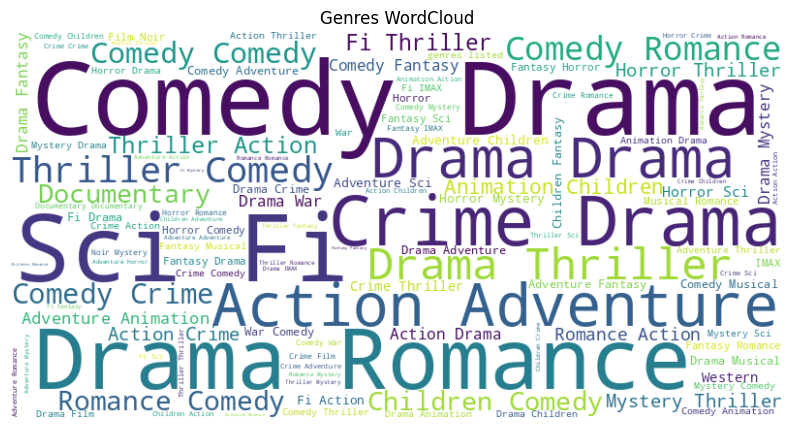

In [17]:
wordcloud(genres_split, 'Genres WordCloud')

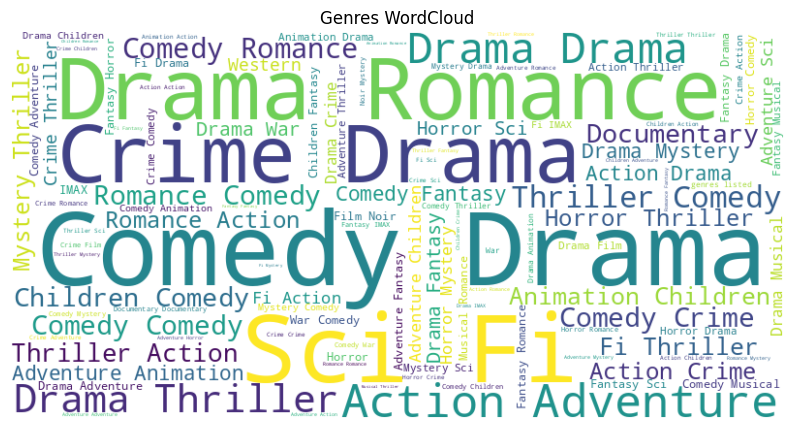

In [18]:
wordcloud(movies.genres, 'Genres WordCloud')

Wordcloud tags

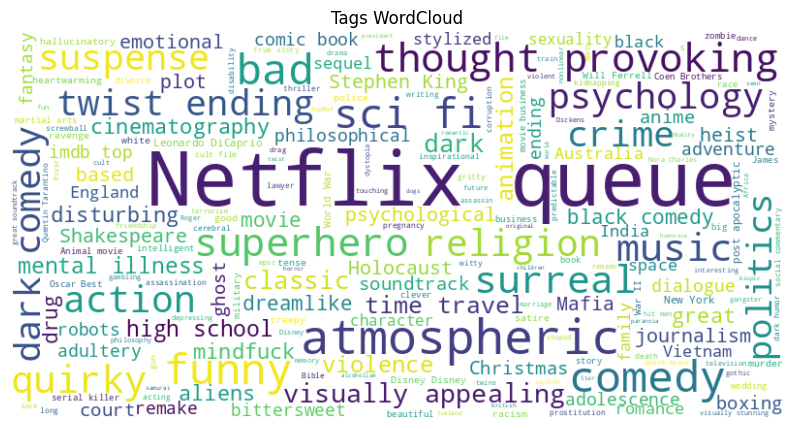

In [19]:
wordcloud(tags.tag, 'Tags WordCloud')

In [20]:
display(movies.head(), ratings.head(), tags.head())

,movieId,title,genres
0,1,Toy Story,Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji,Adventure|Children|Fantasy
2,3,Grumpier Old Men,Comedy|Romance
3,4,Waiting to Exhale,Comedy|Drama|Romance
4,5,Father of the Bride Part II,Comedy


,userId,movieId,rating,timestamp
0,1,1,4.0,2000-07-30 18:45:03
1,1,3,4.0,2000-07-30 18:20:47
2,1,6,4.0,2000-07-30 18:37:04
3,1,47,5.0,2000-07-30 19:03:35
4,1,50,5.0,2000-07-30 18:48:51


,userId,movieId,tag,timestamp
0,2,60756,funny,2015-10-24 19:29:54
1,2,60756,Highly quotable,2015-10-24 19:29:56
2,2,60756,will ferrell,2015-10-24 19:29:52
3,2,89774,Boxing story,2015-10-24 19:33:27
4,2,89774,MMA,2015-10-24 19:33:20


Menggabung data movies dan ratings

In [21]:
movies_ratings = pd.merge(movies, ratings, on='movieId')
display(movies_ratings.head(), movies_ratings.shape)

,movieId,title,genres,userId,rating,timestamp
0,1,Toy Story,Adventure|Animation|Children|Comedy|Fantasy,1,4.0,2000-07-30 18:45:03
1,1,Toy Story,Adventure|Animation|Children|Comedy|Fantasy,5,4.0,1996-11-08 06:36:02
2,1,Toy Story,Adventure|Animation|Children|Comedy|Fantasy,7,4.5,2005-01-25 06:52:26
3,1,Toy Story,Adventure|Animation|Children|Comedy|Fantasy,15,2.5,2017-11-13 12:59:30
4,1,Toy Story,Adventure|Animation|Children|Comedy|Fantasy,17,4.5,2011-05-18 05:28:03


(100836, 6)

Mencari rata rata rating tertinggi film

In [22]:
movies_ratings.groupby('title')['rating'].mean().sort_values(ascending=False).head(10)

,rating
title,
Hollywood Chainsaw Hookers,5.0
"Calcium Kid, The",5.0
Chinese Puzzle (Casse-tête chinois),5.0
Raise Your Voice,5.0
Rain,5.0
Radio Day,5.0
"Thousand Clowns, A",5.0
Hunting Elephants,5.0
Blue Planet II,5.0


Mencari rata rata rating terendah film

In [23]:
movies_ratings.groupby('title')['rating'].mean().sort_values(ascending=True).head(10)

,rating
title,
Anaconda: The Offspring,0.5
"Giant Spider Invasion, The",0.5
"Brothers Solomon, The",0.5
Reptilicus,0.5
Wizards of the Lost Kingdom II,0.5
Superfast!,0.5
Survivor,0.5
Boudu Saved From Drowning (Boudu sauvé des eaux),0.5
Born to Be Wild,0.5


Mencari film yang paling banyak diberi rating

<Axes: xlabel='title'>

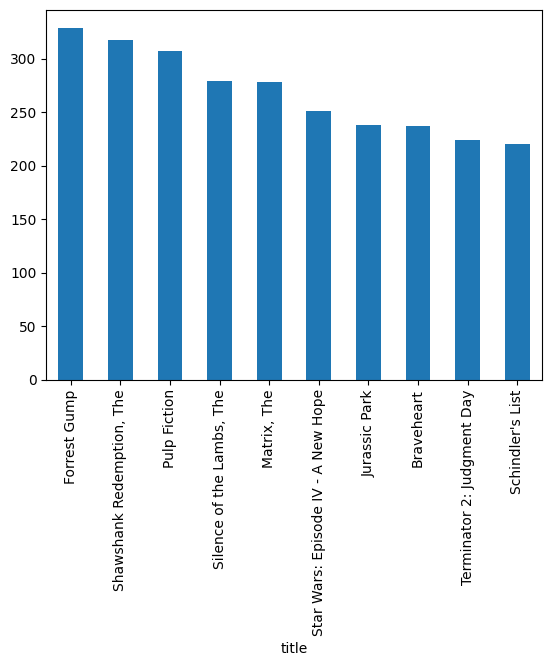

In [24]:
movies_ratings.groupby('title')['rating'].count().sort_values(ascending=False).head(10).plot(kind='bar')

####  <div align="left"><span style="white-space: pre-wrap; font: normal 11pt Arial; line-height: 1.5;">**Insight**: <br>Dari gambar di atas, terlihat bahwa, Forrest Gump mempunyai rating rang paling banyak/span></div>

Kode ini menampilkan DataFrame df setelah penghapusan kolom yang tidak relevan. Langkah ini memungkinkan unutuk memeriksa apakah kolom-kolom yang tidak diperlukan telah berhasil dihapus dan memastikan hanya kolom yang relevan yang tersisa.

In [25]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

tfidf = TfidfVectorizer(stop_words='english')

movies['genres'] = movies['genres'].str.replace(r"[\[\]']", "", regex=True).str.replace("|", " ")

movies['features'] = movies['title'] + " " + movies['genres']
movies.head(6)

,movieId,title,genres,features
0,1,Toy Story,Adventure Animation Children Comedy Fantasy,Toy Story Adventure Animation Children Comedy ...
1,2,Jumanji,Adventure Children Fantasy,Jumanji Adventure Children Fantasy
2,3,Grumpier Old Men,Comedy Romance,Grumpier Old Men Comedy Romance
3,4,Waiting to Exhale,Comedy Drama Romance,Waiting to Exhale Comedy Drama Romance
4,5,Father of the Bride Part II,Comedy,Father of the Bride Part II Comedy
5,6,Heat,Action Crime Thriller,Heat Action Crime Thriller


# **Model Development**

Pada bagian ini mengubah fitur judul film menjadi matriks TF-IDF, lalu menghitung kesamaan antarfilm menggunakan cosine similarity tujuan model ini adalah mencari similarity antara setiap film.

In [26]:
tfidf_matrix = tfidf.fit_transform(movies['features'])
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)
cosine_sim

array([[1.        , 0.2574009 , 0.02187374, ..., 0.        , 0.06022487,
        0.0125025 ],
       [0.2574009 , 1.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.02187374, 0.        , 1.        , ..., 0.        , 0.        ,
        0.0112517 ],
       ...,
       [0.        , 0.        , 0.        , ..., 1.        , 0.        ,
        0.        ],
       [0.06022487, 0.        , 0.        , ..., 0.        , 1.        ,
        0.        ],
       [0.0125025 , 0.        , 0.0112517 , ..., 0.        , 0.        ,
        1.        ]])

Membuat fungsi untuk merekomendasikan 10 film mirip berdasarkan kesamaan judul yang diberikan, menggunakan cosine similarity.

In [38]:
# Fungsi untuk rekomendasi film (Content Based Filtering menggunakan Cosine Similarity)
def recommend_movies(title, cosine_sim=cosine_sim):
    """Dapatkan rekomendasi film berdasarkan cosine similarity."""

    idx = movies[movies['title'] == title].index[0]  # Menemukan index film yang sesuai

    sim_scores = list(enumerate(cosine_sim[idx]))  # Menghitung similarity scores

    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)  # Urutkan berdasarkan similarity

    sim_scores = sim_scores[1:11]  # Ambil 10 film teratas setelah film yang diminta

    movie_indices = [i[0] for i in sim_scores]  # Ambil indeks film yang relevan

    # Mengembalikan DataFrame film yang direkomendasikan
    return movies.iloc[movie_indices][['movieId', 'title', 'genres']]

Kode ini akan menampilkan 10 rekomendasi film yang mirip dengan film berjudul "Toy Story" berdasarkan kesamaan konten film.

In [39]:
recommend_movies("Heat")

,movieId,title,genres
8204,103372,"Heat, The",Action Comedy Crime
2194,2917,Body Heat,Crime Thriller
3345,4531,Red Heat,Action
4587,6814,City Heat,Action Comedy
1427,1950,In the Heat of the Night,Drama Mystery
3322,4497,Dead Heat,Action Comedy Horror Sci-Fi
5207,8491,White Heat,Crime Drama Film-Noir
2815,3763,F/X,Action Crime Thriller
4467,6595,S.W.A.T.,Action Thriller
8057,99005,Fire with Fire,Action Crime Drama


Kode ini akan menampilkan 10 rekomendasi film yang mirip dengan "Jumanji" berdasarkan kesamaan konten film.

In [40]:
recommend_movies("Jumanji")

,movieId,title,genres
9636,179401,Jumanji: Welcome to the Jungle,Action Adventure Children
7039,68954,Up,Adventure Animation Children Drama
6194,45074,"Wild, The",Adventure Animation Children Comedy Fantasy
8800,130450,Pan,Adventure Children Fantasy
7108,70697,G-Force,Action Adventure Children Fantasy
5396,9004,D.A.R.Y.L.,Adventure Children Sci-Fi
3568,4886,"Monsters, Inc.",Adventure Animation Children Comedy Fantasy
26,27,Now and Then,Children Drama
5473,26198,"Yours, Mine and Ours",Children Comedy
5777,31422,Are We There Yet?,Children Comedy


# **Evaluasi Model**

Fungsi-fungsi untuk menghitung metrik evaluasi untuk sistem rekomendasi

In [57]:
# Fungsi evaluasi baru untuk Content-Based Filtering
def precision_recall_content_based(input_movie, recommended_movies, k=10):
    input_tfidf = tfidf.transform([input_movie])
    rec_tfidf = tfidf.transform(recommended_movies)

    # Menghitung cosine similarity antara input dan rekomendasi
    sim_scores = cosine_similarity(input_tfidf, rec_tfidf)[0]

    # Menghitung precision dan recall berdasarkan similarity scores
    precision = sum(sim_scores[:k]) / k
    recall = sum(sim_scores[:k]) / sum(sim_scores) if sum(sim_scores) > 0 else 0

    # Mengembalikan nilai precision dan recall dalam persentase
    return precision * 100, recall * 100

# Contoh penggunaan evaluasi untuk dua film input
input_movies = ["Heat", "Jumanji"]
recommendation_results = {movie: list(recommend_movies(movie)['title']) for movie in input_movies}

for movie in input_movies:
    recommended_titles = recommendation_results[movie]
    precision, recall = precision_recall_content_based(movie, recommended_titles, k=5)
    print(f"Precision@5 for '{movie}': {precision:.2f}%")
    print(f"Recall@5 for '{movie}': {recall:.2f}%")

Precision@5 for 'Heat': 81.97%
Recall@5 for 'Heat': 72.21%
Precision@5 for 'Jumanji': 12.85%
Recall@5 for 'Jumanji': 100.00%


## Collaborative Filtering

In [32]:
from surprise.model_selection import train_test_split
from surprise import SVD, Dataset, Reader
from surprise.model_selection import cross_validate
from surprise.accuracy import rmse, mae

Melatih model SVD untuk rekomendasi film, membagi data menjadi train dan test, lalu menghitung RMSE dan MAE untuk evaluasi akurasi model.

In [53]:
from surprise.model_selection import train_test_split

reader = Reader(rating_scale=(1, 5))
data = Dataset.load_from_df(ratings[['userId', 'movieId', 'rating']], reader)

trainset, testset = train_test_split(data, test_size=0.2, random_state=42)

model = SVD()

model.fit(trainset)

predictions = model.test(testset)
print("Root Mean Squared Error (RMSE):", rmse(predictions))
print("Mean Absolute Error (MAE):", mae(predictions))

RMSE: 0.8790
Root Mean Squared Error (RMSE): 0.8790365176586034
MAE:  0.6756
Mean Absolute Error (MAE): 0.6756366547492019


Fungsi ini merekomendasikan 10 film teratas yang belum pernah ditonton oleh pengguna berdasarkan prediksi rating model.

In [42]:
# Function to recommend movies for a specific user
def get_recommendations(user_id, movies_df, top_n=10):
    user_rated_movies = ratings[ratings['userId'] == user_id]['movieId'].values
    all_movie_ids = movies_df['movieId'].unique()
    unrated_movie_ids = np.setdiff1d(all_movie_ids, user_rated_movies)

    predictions = [model.predict(user_id, movie_id) for movie_id in unrated_movie_ids]
    predictions.sort(key=lambda x: x.est, reverse=True)

    recommended_movie_ids = [pred.iid for pred in predictions[:top_n]]
    recommendations = movies_df[movies_df['movieId'].isin(recommended_movie_ids)]
    return recommendations[['title', 'genres']]

Rekomendasi film untuk user id 1

In [47]:
user_id = 1
recommended_movies = get_recommendations(user_id, movies)
print("Recommended Movies for User", user_id)
recommended_movies

Recommended Movies for User 1


,title,genres
277,"Shawshank Redemption, The",Crime Drama
413,In the Name of the Father,Drama
602,Dr. Strangelove or: How I Learned to Stop Worr...,Comedy War
659,"Godfather, The",Crime Drama
841,"Streetcar Named Desire, A",Drama
906,Lawrence of Arabia,Adventure Drama War
971,Patton,Drama War
975,Cool Hand Luke,Drama
1730,Life Is Beautiful (La Vita è bella),Comedy Drama Romance War
3640,"Beautiful Mind, A",Drama Romance


Rekomendasi film untuk user id 10

In [51]:
user_id = 10
print("Recommended Movies for User", user_id)
recommended_movies

Recommended Movies for User 10


,title,genres
277,"Shawshank Redemption, The",Crime Drama
413,In the Name of the Father,Drama
602,Dr. Strangelove or: How I Learned to Stop Worr...,Comedy War
659,"Godfather, The",Crime Drama
841,"Streetcar Named Desire, A",Drama
906,Lawrence of Arabia,Adventure Drama War
971,Patton,Drama War
975,Cool Hand Luke,Drama
1730,Life Is Beautiful (La Vita è bella),Comedy Drama Romance War
3640,"Beautiful Mind, A",Drama Romance


Rekomendasi film untuk user id 331

In [52]:
get_recommendations(331, movies)

,title,genres
224,Star Wars: Episode IV - A New Hope,Action Adventure Sci-Fi
602,Dr. Strangelove or: How I Learned to Stop Worr...,Comedy War
680,"Philadelphia Story, The",Comedy Drama Romance
841,"Streetcar Named Desire, A",Drama
878,Cinema Paradiso (Nuovo cinema Paradiso),Drama
909,Apocalypse Now,Action Drama War
922,"Godfather: Part II, The",Crime Drama
1494,Seven Samurai (Shichinin no samurai),Action Adventure Drama
2462,"Boondock Saints, The",Action Crime Drama Thriller
7010,Inglourious Basterds,Action Drama War
